# Data Importing and Cleaning  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
print(pd.__version__)

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) 

print("Libraries imported successfully!")

2.0.3
Libraries imported successfully!


In [2]:
df = pd.read_csv('../data/Houses.csv')
print("Data loaded successfully!")
# - Dataset shape (hint: use df.shape)
print("Dataset shape:", df.shape)
# - Number of observations (hint: df.shape[0] gives rows)
print("Number of observations:", df.shape[0])
# - Number of features (hint: df.shape[1] gives columns)
print("Number of features:", df.shape[1])

Data loaded successfully!
Dataset shape: (535, 5)
Number of observations: 535
Number of features: 5


In [3]:
df.head()

,Bedrooms,Bathrooms,SquareFeet,ZipCode,Price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535 entries, 0 to 534
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Bedrooms    535 non-null    int64  
 1   Bathrooms   535 non-null    float64
 2   SquareFeet  535 non-null    int64  
 3   ZipCode     535 non-null    int64  
 4   Price       535 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 21.0 KB


# Detecting and Analyzing Outliers

In [5]:
# features = df.columns.tolist()
# fig, axes = plt.subplots(len(features), 1, figsize=(10, 4*len(features)))


# if len(features) == 1:
#     axes = [axes]
# for i, col in enumerate(features):
#     axes[i].boxplot(df[col].dropna(), vert=False)
#     axes[i].set_ylabel(col)
#     axes[i].set_title(f"Box Plot of {col}")
# plt.tight_layout()
# plt.show()

In [6]:
# def IQR_finding_outliers(df,column):
#     Q1 = np.percentile(df[column].dropna(),25)
#     Q3 = np.percentile(df[column].dropna(),75)
#     IQR = Q3 - Q1 
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
#     return outliers, lower_bound ,upper_bound

# for col in features:
#     outliers, lower_bound, upper_bound = IQR_finding_outliers(df, col)
#     print(f"Column: {col}")
#     print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
#     print(f"Number of outliers found: {outliers.shape[0]}\n")

In [7]:
# for col in features:
#     outliers, lower_bound, upper_bound = IQR_finding_outliers(df, col)
#     df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [8]:
# fig, axes = plt.subplots(len(features), 1, figsize=(10, 4*len(features)))
# if len(features) == 1:
#     axes = [axes]
# for i, col in enumerate(features):
#     axes[i].boxplot(df[col].dropna(), vert=False)
#     axes[i].set_ylabel(col)
#     axes[i].set_title(f"Box Plot of {col}")
# plt.tight_layout()
# plt.show()

In [9]:
y = df['Price'].copy()
X = df.drop('Price', axis=1).copy()
print("Features Shape: ", X.shape)
print("Target Shape: ", y.shape)
print("Target Statistics:\n", y.describe())

Features Shape:  (535, 4)
Target Shape:  (535,)
Target Statistics:
 count    5.350000e+02
mean     5.893628e+05
std      5.090261e+05
min      2.200000e+04
25%      2.492000e+05
50%      5.290000e+05
75%      7.285000e+05
max      5.858000e+06
Name: Price, dtype: float64


In [10]:
skewness_values = X.skew()
print("Skewness of features:", )
skewness_values

Skewness of features:


Bedrooms      0.915318
Bathrooms     1.091190
SquareFeet    1.642034
ZipCode      -3.761110
dtype: float64

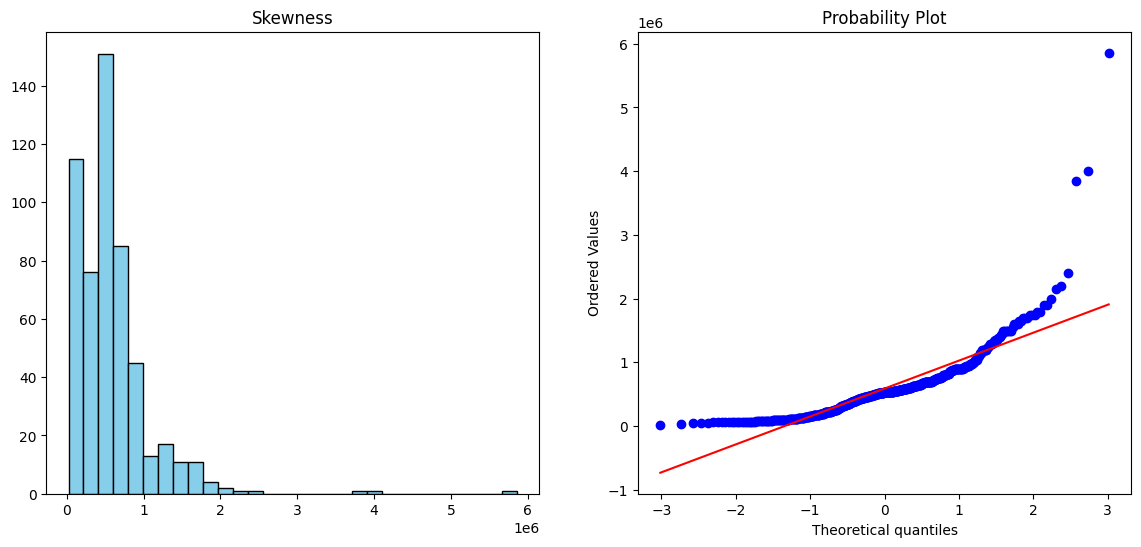

In [11]:
import scipy.stats as stats
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
axis[0].hist(y, bins=30, color='skyblue', edgecolor='black')
axis[0].set_title('Skewness')
stats.probplot(y, dist="norm", plot=axis[1])
plt.show()


there is skewness so log transform aplied


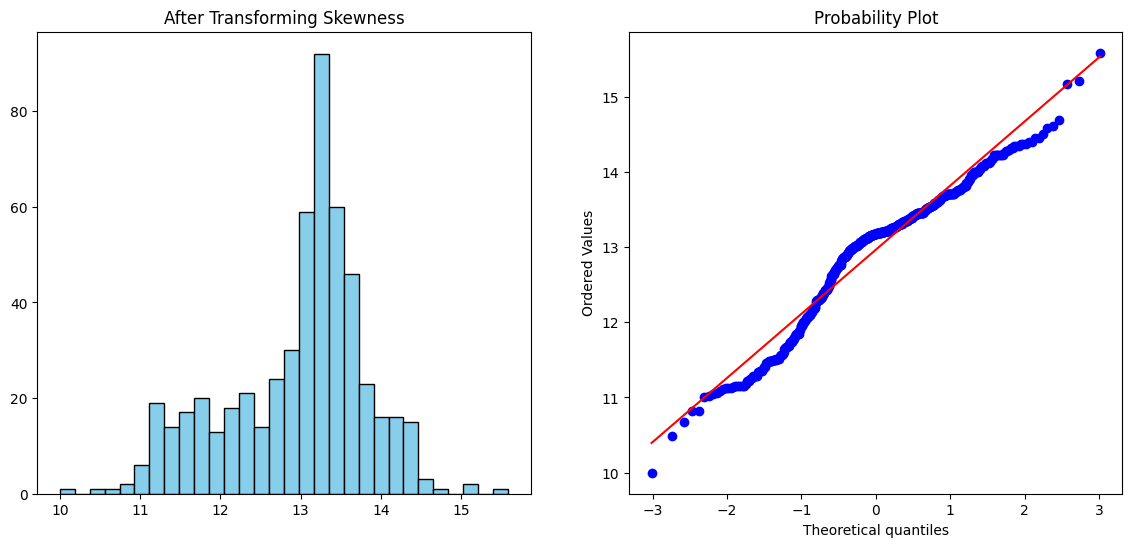

In [12]:
df['Price_log'] = np.log1p(df['Price'])
y = df['Price_log'].copy()
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
axis[0].hist(y, bins=30, color='skyblue', edgecolor='black')
axis[0].set_title('After Transforming Skewness')
stats.probplot(y, dist="norm", plot=axis[1])
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (428, 4) (428,)
Testing set shape: (107, 4) (107,)


In [14]:
zip_mean = y_train.groupby(X_train['ZipCode']).mean()

X_train['ZipCode'] = X_train['ZipCode'].map(zip_mean)
X_test['ZipCode']  = X_test['ZipCode'].map(zip_mean)

global_mean = y_train.mean()
X_train['ZipCode'].fillna(global_mean, inplace=True)
X_test['ZipCode'].fillna(global_mean, inplace=True)

print("ZipCode encoded. Sample values:")
print(X_train['ZipCode'].describe())

tmp = X_train.copy()
tmp['Price_log'] = y_train.values
print("\nCorrelation with Price_log:")
print(tmp.corr()[['Price_log']].sort_values('Price_log', ascending=False))


ZipCode encoded. Sample values:
count    428.000000
mean      12.965237
std        0.759681
min       11.406464
25%       12.515610
50%       13.223303
75%       13.453545
max       14.343194
Name: ZipCode, dtype: float64

Correlation with Price_log:
            Price_log
Price_log    1.000000
ZipCode      0.859467
Bedrooms     0.560642
SquareFeet   0.559933
Bathrooms    0.534340


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline = LinearRegression()
baseline.fit(X_train, y_train)

y_pred_log = baseline.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_exp = np.expm1(y_test)
mae = mean_absolute_error(y_test_exp, y_pred)
mse = mean_squared_error(y_test_exp, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_exp, y_pred)

print("── Linear Regression Baseline ──")
print(f"MAE  : ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"R²   : {r2:.3f}")

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': baseline.coef_
}).sort_values('coefficient', ascending=False)

print(coef_df)



── Linear Regression Baseline ──
MAE  : $159,225
RMSE : $241,089
R²   : 0.580
      feature  coefficient
3     ZipCode     0.856393
1   Bathrooms     0.059280
0    Bedrooms     0.047755
2  SquareFeet     0.000112


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = np.expm1(rf.predict(X_test))
y_actual  = np.expm1(y_test)


mae_rf  = mean_absolute_error(y_actual, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_actual, y_pred_rf))
r2_rf   = r2_score(y_actual, y_pred_rf)


print("── Random Forest Regressor ──")
print(f"MAE  : ${mae_rf:,.0f}")
print(f"RMSE : ${rmse_rf:,.0f}")
print(f"R²   : {r2_rf:.3f}")
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importances)

── Random Forest Regressor ──
MAE  : $113,980
RMSE : $184,846
R²   : 0.753
      feature  importance
3     ZipCode    0.539114
2  SquareFeet    0.219617
0    Bedrooms    0.178528
1   Bathrooms    0.062741


In [17]:
from sklearn.model_selection import RandomizedSearchCV, KFold

param_grid = {
    'n_estimators':      [400, 500, 600],
    'max_depth':         [8, 10, 12],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf':  [1, 2, 3],
    'max_features':      [0.5, 'sqrt'],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_grid,
    n_iter=40,
    scoring='r2',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)
print(f"\nBest cross-validation R²: {search.best_score_:.3f}")

best_rf = search.best_estimator_

y_pred_tuned = np.expm1(best_rf.predict(X_test))
y_actual     = np.expm1(y_test)

mae_tuned  = mean_absolute_error(y_actual, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_actual, y_pred_tuned))
r2_tuned   = r2_score(y_actual, y_pred_tuned)

print(f"\n{'Metric':<8} {'Linear Reg':>12} {'RF Default':>12} {'RF Tuned':>12}")
print("-" * 48)
print(f"{'MAE':<8} ${mae:>11,.0f} ${mae_rf:>11,.0f} ${mae_tuned:>11,.0f}")
print(f"{'RMSE':<8} ${rmse:>11,.0f} ${rmse_rf:>11,.0f} ${rmse_tuned:>11,.0f}")
print(f"{'R²':<8} {r2:>12.3f} {r2_rf:>12.3f} {r2_tuned:>12.3f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits


Best parameters:
{'n_estimators': 500, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}

Best cross-validation R²: 0.837

Metric     Linear Reg   RF Default     RF Tuned
------------------------------------------------
MAE      $    159,225 $    113,980 $    113,576
RMSE     $    241,089 $    184,846 $    179,748
R²              0.580        0.753        0.767


In [18]:
final_rf = search.best_estimator_
final_rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=3, n_estimators=500, n_jobs=-1,
                      random_state=42)

      feature  importance       std
3     ZipCode    0.539220  0.215093
2  SquareFeet    0.217136  0.165423
0    Bedrooms    0.177890  0.192114
1   Bathrooms    0.065753  0.077287


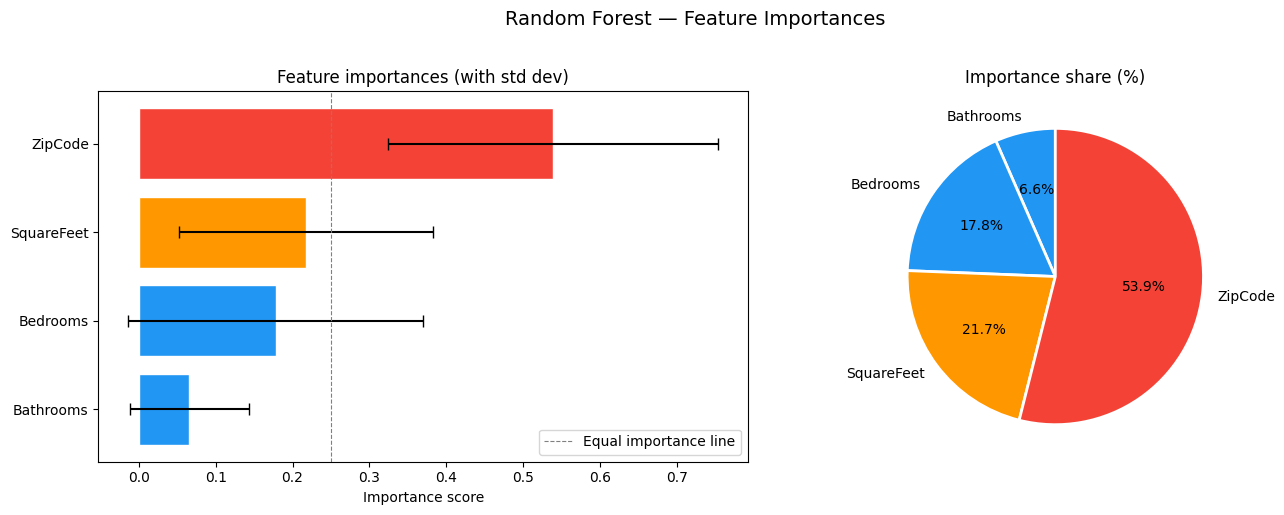

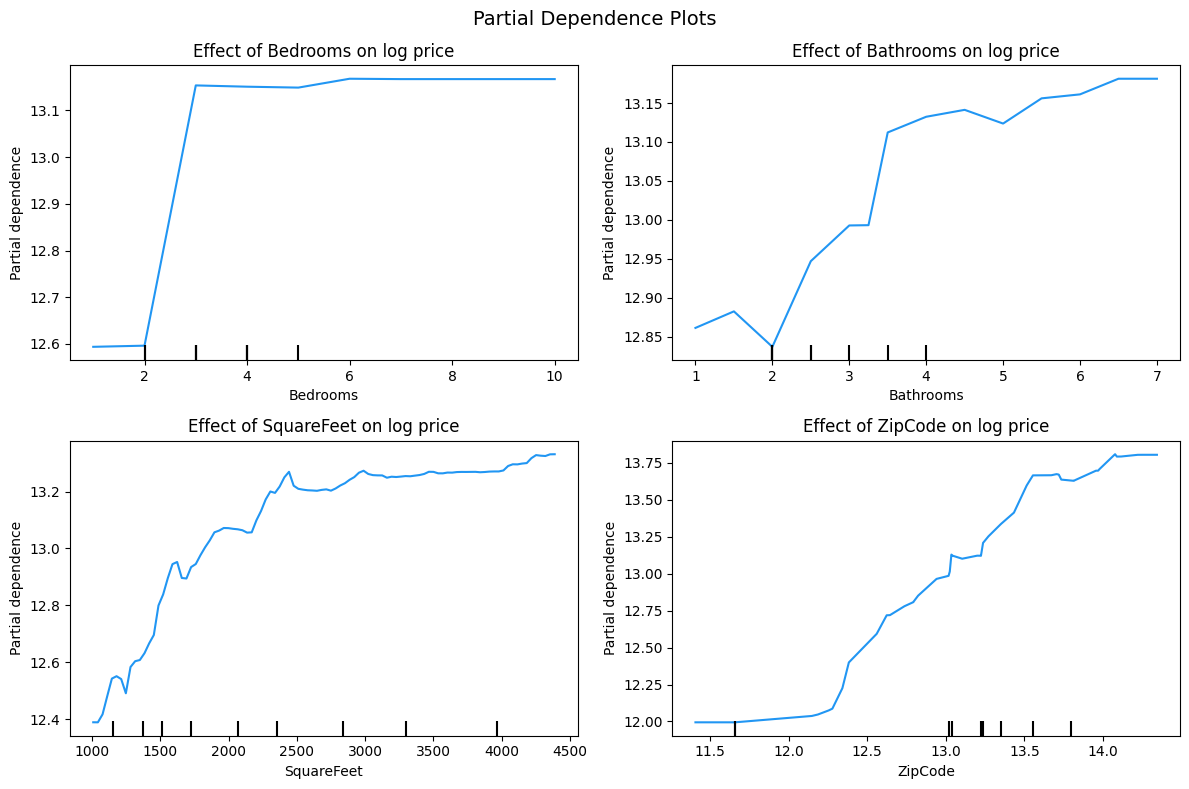

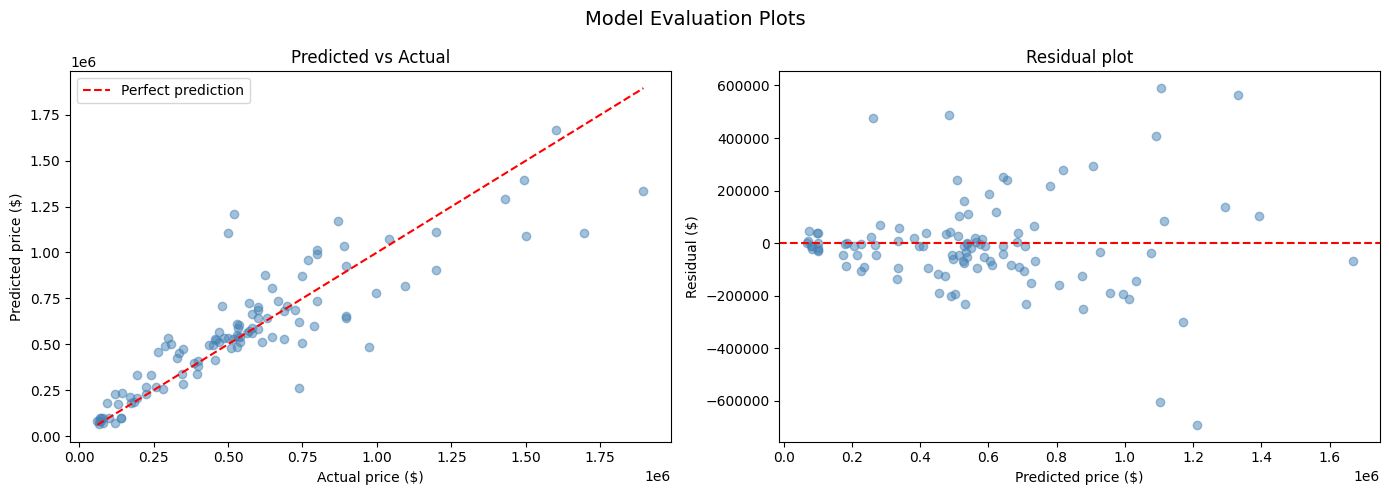

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── 1. Extract importances ────────────────────────────────────
features = ['Bedrooms', 'Bathrooms', 'SquareFeet', 'ZipCode']

importances = final_rf.feature_importances_
std         = np.std([tree.feature_importances_ for tree in final_rf.estimators_], axis=0)

importance_df = pd.DataFrame({
    'feature':    features,
    'importance': importances,
    'std':        std
}).sort_values('importance', ascending=True)

print(importance_df.sort_values('importance', ascending=False))

# ── 2. Bar chart with error bars ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: horizontal bar chart
axes[0].barh(
    importance_df['feature'],
    importance_df['importance'],
    xerr=importance_df['std'],
    color=['#2196F3', '#2196F3', '#FF9800', '#F44336'],
    edgecolor='white',
    capsize=4
)
axes[0].set_xlabel('Importance score')
axes[0].set_title('Feature importances (with std dev)')
axes[0].axvline(x=0.25, color='gray', linestyle='--',
                linewidth=0.8, label='Equal importance line')
axes[0].legend()

# Right: pie chart for share breakdown
axes[1].pie(
    importance_df['importance'],
    labels=importance_df['feature'],
    autopct='%1.1f%%',
    colors=['#2196F3', '#2196F3', '#FF9800', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Importance share (%)')

plt.suptitle('Random Forest — Feature Importances', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Partial dependence: how each feature affects price ─────
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
axes_flat = ax.flatten()

for i, feature in enumerate(features):
    PartialDependenceDisplay.from_estimator(
        final_rf, X_train,
        features=[i],
        ax=axes_flat[i],
        line_kw={'color': '#2196F3'}
    )
    axes_flat[i].set_title(f'Effect of {feature} on log price')
    axes_flat[i].set_xlabel(feature)

plt.suptitle('Partial Dependence Plots', fontsize=14)
plt.tight_layout()
plt.show()

# ── 4. Prediction error plot ──────────────────────────────────
y_pred_final = np.expm1(final_rf.predict(X_test))
y_actual     = np.expm1(y_test)
residuals    = y_actual - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_actual, y_pred_final, alpha=0.5, color='steelblue')
axes[0].plot([y_actual.min(), y_actual.max()],
             [y_actual.min(), y_actual.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual price ($)')
axes[0].set_ylabel('Predicted price ($)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Residuals
axes[1].scatter(y_pred_final, residuals, alpha=0.5, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual plot')

plt.suptitle('Model Evaluation Plots', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

y_pred_xgb = np.expm1(xgb.predict(X_test))

print(f"XGBoost R²:  {r2_score(y_actual, y_pred_xgb):.3f}")
print(f"XGBoost MAE: ${mean_absolute_error(y_actual, y_pred_xgb):,.0f}")

/home/bayram/Desktop/AI_Project/.venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


XGBoost R²:  0.778
XGBoost MAE: $109,700


In [23]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = np.expm1(lgbm.predict(X_test))

print(f"LightGBM R²:  {r2_score(y_actual, y_pred_lgbm):.3f}")
print(f"LightGBM MAE: ${mean_absolute_error(y_actual, y_pred_lgbm):,.0f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 193
[LightGBM] [Info] Number of data points in the train set: 428, number of used features: 4
[LightGBM] [Info] Start training from score 12.965237
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [22]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVR requires scaling unlike RF/XGBoost
scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)

y_pred_svr = np.expm1(svr.predict(X_test_scaled))

print(f"SVR R²:  {r2_score(y_actual, y_pred_svr):.3f}")
print(f"SVR MAE: ${mean_absolute_error(y_actual, y_pred_svr):,.0f}")

SVR R²:  0.533
SVR MAE: $154,732


In [24]:
from sklearn.ensemble import StackingRegressor

estimators = [
    ('rf',   final_rf),
    ('xgb',  xgb),
    ('lgbm', lgbm),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=5
)

stack.fit(X_train, y_train)
y_pred_stack = np.expm1(stack.predict(X_test))

print(f"Stacking R²:  {r2_score(y_actual, y_pred_stack):.3f}")
print(f"Stacking MAE: ${mean_absolute_error(y_actual, y_pred_stack):,.0f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 193
[LightGBM] [Info] Number of data points in the train set: 428, number of used features: 4
[LightGBM] [Info] Start training from score 12.965237
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [26]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np

# ── 1. Parameter grid ─────────────────────────────────────────
param_grid = {
    'n_estimators':      [300, 500, 700, 1000],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [4, 6, 8, 10],
    'num_leaves':        [15, 31, 50, 63],
    'min_child_samples': [10, 20, 30],
    'subsample':         [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
    'reg_alpha':         [0, 0.1, 0.5],      # L1 regularization
    'reg_lambda':        [0, 0.1, 0.5, 1.0], # L2 regularization
}

# ── 2. Search ─────────────────────────────────────────────────
cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42, verbose=-1),
    param_distributions=param_grid,
    n_iter=30,
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)
print(f"\nBest CV R²: {search.best_score_:.3f}")

# ── 3. Evaluate on test set ───────────────────────────────────
best_lgbm = search.best_estimator_

y_pred_tuned = np.expm1(best_lgbm.predict(X_test))
y_actual     = np.expm1(y_test)

mae_tuned  = mean_absolute_error(y_actual, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_actual, y_pred_tuned))
r2_tuned   = r2_score(y_actual, y_pred_tuned)

# ── 4. Comparison ─────────────────────────────────────────────
print(f"\n{'Model':<25} {'R²':>8} {'MAE':>14}")
print("-" * 49)
print(f"{'Linear Regression':<25} {0.580:>8.3f} ${159225:>13,.0f}")
print(f"{'Random Forest tuned':<25} {0.767:>8.3f} ${113576:>13,.0f}")
print(f"{'LightGBM default':<25} {0.785:>8.3f}")
print(f"{'LightGBM tuned':<25} {r2_tuned:>8.3f} ${mae_tuned:>13,.0f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


KeyboardInterrupt: 